# ¿ Qué es NLP?

Imposible arrancar un tema sin sentar el ground zero, es decir sin establecer la verdad minima que define el resto de lo que vamos a aprender.

El Procesamiento del Lenguaje Natural (NLP) es la rama de la Inteligencia Artificial que permite a las computadoras interpretar, comprender y generar el lenguaje humano.

Simple y corto, si queremos comunicarnos con un sistema/aplicación/modelo  debemos poder convertir nuestra estructura de datos (nuestras oraciones) en una estructura de datos que pueda ser trabajada por nuestros sistemas.

Lo primero que sabemos es que ningun sistema, nisiquiera los modelos mas modernos de LLM pueden comprender lo que decimos, ni comprenden lo que nos dicen.

La comunicación entre un sistema y una persona desde un principio se baso en identificar patrones en la comunicación humana que puedan ser clasificados por los sistemas y a partir de esta clasificación se puedan tomar acciones en respuesta.

Con el paso de los años cambiaron las tecnicas para identificar patrones, pero el concepto central nunca se modifico, no hay un proceso de comprensión al nivel humano en el cual se genera una abstracción conceptual de un objeto, propiedad, o acción y se convierte este concepto abstracto en un conjunto de caracteres o fonemas que lo representa.

Las personas identifican un objeto y crean millones de asociaciones diferentes al mismo, por sus propiedades, por lo que sabe previamente o aprende sobre la marcha de el, por lo que le hace sentir, por lo que recuerda y por lo que imagina. Todas estas dimenciones le permiten a la persona encontrar cercanias, parecidos, coincidencias, y diferencias entre los distintos objetos, y asi tambien acciones, sentimientos, y todo aquello que podemos describir sea material,inmaterial o abstracto.
Los sistemas de computadora toman conocimiento de la existencia del universo a travez de los datos que reciben, no ven mas que una sombra de la realidad y sobre la misma es que crean su base de conocimiento y relaciones sobre el mundo.
La sombra sobre la que aprenden va a estar determinada por los objetos que usemos para entrenar a los modelos, la luz con la cual los iluminemos, e incluso el angulo con el que los enfoquemos. Asi es que los sistemas no pueden interpretar la realidad por la experiencia como lo realizan los humanos sino que por lo que le decimos que es la realidad.

El primer paso para poder mostrarle las sombras al modelo y empiece a conocer el mundo es a travez de la Programación del Lenguage Natural (PLN - NLP)

Mucho antes de la aparición de los grandes modelos, los LLM, ya se utilizaba ampliamente tecnicas de PLN para comunicarse con sistemas, procesar textos , y sobre todo identificar caracteristicas en los textos.

Estas técnicas no han desaparecido, si bien los LLM pueden resolver de forma mucho mas certera la mayoria (para no decir todas) las tareas que se realizaban mediante tecnicas AISLADAS de PLN, un LLM sigue siendo un sistema costoso en terminos de procesamiento, en terminos de latencia, y sobre todo en terminos economicos.

Por eso es muy importante conocer, entender, y manejar distintas tecnicas de PLN que hay a nuestra disposición que por ser especializadas en tareas particulares no requieren tanto poder de computo y pueden ser una herramienta invaluable para reducir costos y tiempos en tareas de preprocesamiento, filtrado, detección y sintaxis de datos en formato de lenguaje natural.

  
>*No es necesario alquilar una pala mecanica para plantar un limonero, con una pala y un poco de paciencia se logra lo mismo sin gastar de mas*

# TOKENIZACION


Para iniciar con el resto de las explicaciones primero tenemos que hablar de como se identifica una unidad de texto, es decir para poder trabajar en PLN debemos pasar del concepto de palabra a un concepto abstracto que nos permita manipular los datos, asi se crea la idea de **token**.

Un token es la unidad básica en la que un modelo de lenguaje “lee” y “escribe” texto.

- Un modelo no ve palabras completas
 ve fragmentos de texto (tokens),tokenizar es el proceso de transformar texto en unidades que el modelo puede entender.



> **Técnicas principales de tokenización**

1. Word-based (por palabra)


es la más intuitiva

>> "hola mundo" → ["hola", "mundo"]

✔️ simple

❌ no maneja bien palabras nuevas

2. Character-based (por carácter)

"h", "o", "l", "a"

✔️ robusto

❌ secuencias muy largas

3. Subword tokenization (la moderna)

La más usada hoy (LLMs)

"transformación" →
["trans", "form", "ación"]

✔️ balance perfecto

✔️ maneja palabras nuevas

✔️ eficiente


>>Algoritmos de subword más usados

🔹 BPE (Byte Pair Encoding)

>>Más clásico

🔹 WordPiece

>> Usado en BERT

🔹 Unigram (SentencePiece)

>>Usado en muchos modelos modernos


###Librerías para tokenización

**NLTK (clásica / académica)**

Una de las primeras librerías de NLP en Python

tokenización por palabras

tokenización por frases

stopwords

stemming




In [22]:
# Ejemplo de tokenizacion con nltk
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
texto = "Factura 1234 cliente Juan Perez"
tokens = word_tokenize(texto)

print(tokens)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['Factura', '1234', 'cliente', 'Juan', 'Perez']


**spaCy (industrial / moderna clásica)**

Mucho más usada en producción PLN tradicional

tokenización inteligente

lematización

POS tagging

pipelines completos


In [25]:
# Ejemplo de tokenizacion con spacy

!python -m spacy download es_core_news_sm

import spacy

nlp = spacy.load("es_core_news_sm")
doc = nlp("Factura 1234 cliente Juan Perez")

tokens = [token.text for token in doc]
print(tokens)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 79.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
['Factura', '1234', 'cliente', 'Juan', 'Perez']


**Tokenizers de Transformers (la moderna real)**

Usados en LLMs (BERT, GPT, etc.)

Hugging Face Transformers

tokenización subword (BPE, WordPiece)

conversión a IDs

preparación para embeddings


In [26]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

tokens = tokenizer.tokenize("factura cliente juan")
print(tokens)

ids = tokenizer.encode("factura cliente juan")
print(ids)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

['fact', '##ura', 'client', '##e', 'juan']
[101, 2755, 4648, 7396, 2063, 5348, 102]


# TECNICAS DE PLN

## 🧠 Principales técnicas de OLN

| Técnica | Tipo | Qué hace | Ventajas | Limitaciones | Ejemplo |
|--------|------|---------|----------|--------------|---------|
| 🔤 Regex | Sintáctica | Busca patrones exactos en texto | Muy precisa | No entiende significado | Detectar "FACTURA 1234" |
| 🧾 Bag of Words | Estadística | Representa texto como conteo de palabras | Simple | Pierde orden y contexto | "hola mundo" = ["hola", "mundo"] |
| 📊 TF-IDF | Estadística | Pondera palabras según importancia | Mejor que BoW | Sigue sin semántica | Destacar palabras clave |
| 🏷️ NER | Lingüística | Detecta entidades (personas, lugares) | Útil en datos estructurados | Depende del idioma/modelo | "Juan Perez" → PERSONA |
| 🧠 Embeddings | Semántica | Representa significado en vectores | Captura contexto | Más complejo | "auto" ≈ "coche" |
| 🔎 Búsqueda semántica | Aplicación | Encuentra texto similar por significado | Flexible | Puede fallar en precisión | Buscar documentos similares |
| 🤖 LLMs | Generativa | Entienden y generan lenguaje | Muy potente | Costoso / no determinista | ChatGPT |


-----------

El cuadro anterior describe las principales tecnicas que se estan usando para poder procesar el lenguaje natural, no todas sirven para lo mismo, su especificidad es lo que permite que sean eficientes.

Vemos que en el nivel mas alto tenemos los LLM de los que ya hablamos, es la pala mecanica. Sirve para todo, pero tiene un precio muy alto por ejecución.

Ahora vamos a ir de menos a más revisando su uso, funcionamiento y ejemplos minimos.

## REGEX

Es una tecnica que no utiliza ningun principio probabilistico para resolver la necesidad, es completamente determinista. Tenemos un conjunto de reglas asociadas a caracteres y si se encuentra una coincidencia que responda a esas reglas dictadas, se ejecuta una acción.

Si bien es algo basico, que en general la mayoria de las personas lo han usado, no es una herramienta para subestimar.

Ejecutar una busqueda mediante REGEX si bien es muy limitada, puede ser una solución sumamente eficiente, dependera de la estructura de datos que tengamos.

La pregunta seria:
>Si los datos a consultar tienen una estructura de datos bien definida ¿Para qué voy a gastar tiempo de computo en llamar a un LLM?

REGEX no puede reemplazar las bondades de un LLM, pero en casos particulares puede ser una solucion mucho mas rapida y económica.
Entonces una vez mas... si se puede resolver con regex, hay que priorizar esta opción.

## BAG OF WORDS

El principio basico es: contar cuantas veces aparece una palabra en un documento/texto

El criterio seria: mas veces aparece una palabra...mas importante es, o por lo menos representativa dentro del texto.
Lo que logramos  es poder operar desde un punto de vista estadistico con las palabras, pero no tenemos información adicional sobre estas, su utilidad,significado, relación, estas caracteristicas se pierden con esta técnica.

Algunos de los analisis que se realizan con Bag of Words pueden ser
- Binario : Exisencia o no de una palabra en un texto
- Frecuencia: Cantidad de veces que aparece sobre el total de palabras
- N-Gramas: Evaluación binaria o de frecuencia pero de un conjunto de N palabras

Vemos un ejemplo simple



In [ ]:
# Importamos la libreria de sklearn para convertir las palabras en vectores
from sklearn.feature_extraction.text import CountVectorizer

# Definimos los datos que vamos a analizar
docs = ["juan compra pan", "juan compra leche"]

# Creamos el objeto countvectorizer para la transformacion
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(docs)

feature_names = vectorizer.get_feature_names_out()
# Convertirmos el resultado en un array de datos para su manipulacion
X_array = X.toarray()

print(feature_names)

print(" --- CANTIDAD DE OCURRENCIAS DE CADA PALABRA ---")
print(X_array)
print("---------\n")

print(" --- FRECUENCIA DE OCURRENCIA DE CADA PALABRA ---")

for i, doc in enumerate(docs):
    total_palabras = X_array[i].sum()
    frecuencia = X_array[i] / total_palabras

    print(f"\nDocumento: {doc}")
    print(frecuencia)


['compra' 'juan' 'leche' 'pan']
 --- CANTIDAD DE OCURRENCIAS DE CADA PALABRA ---
[[1 1 0 1]
 [1 1 1 0]]
---------

 --- FRECUENCIA DE OCURRENCIA DE CADA PALABRA ---

Documento: juan compra pan
[0.33333333 0.33333333 0.         0.33333333]

Documento: juan compra leche
[0.33333333 0.33333333 0.33333333 0.        ]



Podemos ver que nos devuelve dos vectores (listas) donde cada elemento representa la cantidad de veces que figura una palabra determinada en cada oración, esto podria convertirse sin dificultad luego en un analisis de frecuencia, evaluar las palabras mas usadas, los considerables outliers, etc.

## TF-IDF Frecuencia de término - Frecuencia inversa de documento

TF-IDF es una técnica que mide qué tan importante es una palabra en un documento considerando todo el conjunto de documentos. Vuelve a analizar las palabras por su ocurrencia sin considerar la ubicación ni valor semantico o sintactico de las mismas.
Difiere del bag of words porque agrega un proceso estadistico al ponderar cada palabra, la intención es definir la importancia de una palabra dentro del contexto por su ocurrencia, esto no evalua su importancia real en el contexto del lenguaje, sino desde un punto de vista estadistico.

>>"factura cliente juan monto total"

“cliente” aparece en todos los documentos → ❌ poco relevante

“juan” aparece en pocos → ✅ muy relevante

-------------

>¿Como se analiza esto?

Term Frequency - Frecuencia en el documento

$$ TF = \frac{\text{veces que aparece}}{\text{total de palabras}}$$


Inverse Document Frequency - Frecuencia Inversa


$$\text{IDF} = \log\left(\frac{\text{total documentos}}{\text{documentos con la palabra}}\right)$$


Matematicamente el coeficiente es el resultado de

>>>TF-IDF = TF × IDF

 Materialicemos esto en un ejemplo

Doc1: "juan compra pan"
Doc2: "juan compra leche"

>“juan” y “compra”

aparecen en todos los docs → IDF bajo

> “pan” y “leche”:

aparecen en uno solo → IDF alto


Esta tecnica permite buscar dentro de los documentos palabras que podrian, bajo determinados contextos y utilidades, ser relevantes.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

docs = [
    "juan compra pan",
    "juan compra leche"
]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(docs)

print(vectorizer.get_feature_names_out())
print(X.toarray())


# para una mejor visual
x = vectorizer.get_feature_names_out()
y = X.toarray()

print("*********************")

print("       Doc1 | Doc2")
for i in range(len(x)):
    print(f"{x[i]}, {y[0][i]:.3f} | {y[1][i]:.3f}")




['compra' 'juan' 'leche' 'pan']
[[0.50154891 0.50154891 0.         0.70490949]
 [0.50154891 0.50154891 0.70490949 0.        ]]
*********************
       Doc1 | Doc2
compra, 0.502 | 0.502
juan, 0.502 | 0.502
leche, 0.000 | 0.705
pan, 0.705 | 0.000


Podriamos decir que TF-IDF nos dice qué palabras importan, pero no qué significan.

Un uso interesante para este modelo es crear tags o clasificar textos al considerar que las palabras con mayor valor de TF-IDF no se encuentran con tanta frecuencia en otros archivos y son representativos como discriminantes.

Un excelemte complemento para comprender de forma mas profunda el significado del TF-IDF es el contenido: https://www.tidytextmining.com/tfidf

## NER (Reconocimiento de Entidades Nombradas)

Una entidad nombrada es un fragmento de texto que puede ser identificada dentro de una categoria especifica.


Partimos del texto *"Juan Perez trabaja en Google desde 2024, anteriormente trabajo en ACME SA en la ciudad de Buenos Aires, Argentina desde el 12/05/2023. Antes ganaba $1500 pero ahora le pagan 3200 pesos "*

- Personas
"Juan Perez"
- Organizaciones
"ACME SA", "Google"
- Lugares
"Argentina", "Buenos Aires"
- Fechas
"2024", "12/05/2023"
- Cantidades
"$1500", "3200 pesos"

-----------


Desde un punto de vista tecnico:
>NER (Named Entity Recognition) es una técnica de NLP que identifica y clasifica entidades dentro de un texto.

¿Pero que es una entidad?

Una entidad es cualquier elemento del mundo real que puede ser identificado de manera única dentro de un texto.

Juan Perez → Persona

factura 1234 → Identificador / documento

Córdoba → Lugar

Palabras como:

"pagó", "la", "en"

NO son entidades porque:

No representan objetos concretos
No se pueden identificar como “algo del mundo real”


Cuando hablamos de NER hacemos referencia a una tecnica de analisis del texto, pero la forma en que llegamos a desarrollar esa tecnica (como logramos detectar y clasificar cada entidad) es totalmente unica,adaptable y maleable al uso que tengamos.

Metodos basicos pueden incluir

Detección por reglas gramaticales (variables segun el idioma utilizado)

Detección por reglas semanticas, de orden, caracteres y cercania entre palabras

Detección mediante modelos de aprendizaje automatico

Detección hibrida, aplicando mas de una metodologia al mismo tiempo.

Para fines practicos tenemos a disposición librerias que resuelven de forma rapida y eficiente la detección de entidades, lo que no quita que no pueda entrenarse un modelo propio con datos orientados a identificar y clasificar entidades basado en nuestros criterios de selección y los datos propios de entreno.

Vamos a citar algunas de las librerias mas difundidas y utilizadas como ejemplos:

- Natural Language Toolkit (NLTK)
NLTK es una plataforma líder de código abierto para crear programas Python para trabajar con datos de lenguaje humano.

- Stanford Named Entity Recognizer
Modelo basado en Java para la detección de entidades

- SpaCy
Cuenta con un sistema estadístico avanzado que permite a los usuarios crear extractores de NER personalizados.


Un ejemplo de codigo para practicar es:

[02_Ejemplo_NER](
https://colab.research.google.com/drive/10lLQrRxG5GTwFh1RoxuqJzKyHAxUT2Ra?usp=sharing)

Una buena opción para ampliar este contenido es:

https://openwebinars.net/blog/named-entity-recognition-ner/


Si bien se puede usar modelos de LLM para realizar esta tarea, la intención es optimizar los recursos por lo que lo ideal es usar librerias especificar para esto o entrenar un modelo liviano.

## EMBEDDINGS

Ya cuando empezamos con NER el tema se volvia interesante, ahora con embeddings ya subimos de nivel y comenzamos a tratar tecnicas que se aplican mucho en el día a día

Esta es la primer tecnica en la cual se le intenta dar un sentido a las palabras en el contexto del oración.

Un embedding es una representación numérica (vector) de un texto que captura su significado.

Al convertir una palabra en un embedding transformamos la misma en un vector de N dimenciones que representa su relación con otras palabras dentro del universo (corpus) de palabras analizadas
**"perro"** → [0.2, -0.1, 0.8, ...]

**"gato"**  → [0.25, -0.05, 0.75, ...]


Cada dimensión en un embedding representa, matemáticamente, un "rasgo" o "característica" abstracta del significado de la palabra.

Pocas dimensiones (por ejemplo, 50 o 100) producen un espacio muy chico.

El modelo solo podrá agrupar las palabras en categorías muy groseras (ej. "cosas vivas" vs. "cosas inanimadas").

Usando mas dimenciones (por ejemplo, 300, 768 o 1536), se le esta dando al modelo más "coordenadas" para capturar sutilezas abstractas: ironía, tiempos verbales, contexto geográfico, género, formalidad, etc.

Cada dimensión del vector captura características semánticas como por ejemplo:

- Género
- Tamaño
- Tipo de objeto
- Contexto de uso

No son interpretables directamente, pero el conjunto sí tiene sentido

La cantidad de dimensiones debe ser proporcional al volumen de texto del que va a aprender el modelo:

Modelos chicos/específicos: Al entrenar un modelo con técnicas tradicionales (como Word2Vec o FastText) usando solo los artículos de un diario , usar 300 dimensiones puede ser un estándar logico. Si le ponés 1,500 dimensiones a un dataset chico, el modelo va a sufrir de overfitting, porque va a tener demasiadas variables para tan pocos datos.

Los modelos modernos (como BERT, GPT o Llama) se entrenan con todos los datos que se logran scrappear de internet. Al haber tanta variedad de lenguaje, necesitan espacios vectoriales masivos.

Desarrollar un modelo de embedding "casero" es muy poco eficiente y trae mas dificultades que bondades, por lo que se suelen utilizar modelos ya armados como:

- **spaCy (es_core_news_md / lg)**: Utilizan 300 dimensiones. Es el número clásico y óptimo para embeddings estáticos basados en vectores de palabras.

- **BERT (Base)**: Utiliza 768 dimensiones.

- **OpenAI (text-embedding-3-small / large)**: Utilizan 1,536 o hasta 3,072 dimensiones respectivamente.


El siguiente codigo muestra un ejemplo de como se puede entrenar un modelo de Embeddings, de esta manera entender mejor lo que sucede por detras de los modelos mas grandes.

[02_CREACION_DE_EMBEDDING](https://colab.research.google.com/drive/1B4v5VKyK97AWB6M0q2cLIJFr20dW_dfU?usp=sharing)

Se puede ampliar el concepto y ver mas datos de las tecnicas en:

https://openwebinars.net/blog/embeddings/

## Busqueda Semantica

La búsqueda semántica es una técnica que permite encontrar información basándose en el significado del texto, en lugar de coincidencia exacta de palabras. Es la capacidad del sistema de buscar palabras,oraciones, y conceptos similares segun la proximidad semantica de las palabras.

En el contexto de la inteligencia artificial y los sistemas de información, la semántica se refiere al significado real, la intención y el contexto que hay detrás de las palabras, yendo mucho más allá de las letras individuales que las componen.

Para entenderlo de forma simple: la búsqueda tradicional (por palabras clave o keyword matching) es "ciega" al significado; solo busca coincidencias ortográficas exactas. En cambio, la búsqueda semántica intenta comprender el texto de la misma manera que lo haría un ser humano.

**Búsqueda Sintáctica (Palabras clave)**: Si alguien busca "computadora portátil barata", el sistema tradicional busca la aparición exacta de esas palabras. Si un artículo dice "notebook económica en oferta", el buscador tradicional no lo encuentra porque las palabras no coinciden letra por letra, a pesar de que el significado es exactamente el mismo.

**Búsqueda Semántica**: Entiende que "computadora portátil" y "notebook" son sinónimos, y que "barata" y "económica" apuntan al mismo concepto conceptual. El sistema devuelve el artículo correcto porque busca significados, no caracteres.

Como estuvimos viendo hace momentos en la creación de embeddings, las palabras pueden ser representadas en un espacio vectorial de N dimenciones que describe la relacion de la palabra en el contexto en el que se encuentra, como paso con la palabra rey y la palabra reina, podemos encontrar sinonimos, palabras similares, o con intencionalidades parecidas, solamente por medir la distancia entre estos vectores. Como las distancias por si mismo no dicen nada, obtenemos la distancia entre una palabra y todas las otras que nos interesan y asi generamos un listado de mayor a menor de cuales estan mas cerca y cuales mas lejos.

No significa que una palabra porque este arriba en el ranking sea la solución esperable... pero si podemos esperar que entre las primeras opciones se encuentre la mejor palabra para solucionar nuestra busqueda

### 📊 Fenómenos Lingüísticos en la Búsqueda Semántica

| Fenómeno | Explicación | Ejemplo de Búsqueda Semántica |
| :--- | :--- | :--- |
| **Sinonimia** | Palabras distintas con el mismo significado. | Al buscar *"remedio para la jaqueca"*, el sistema recupera documentos que hablan de *"analgésicos para la migraña"*. |
| **Polisemia / Homonimia** | Una misma palabra con múltiples significados según el contexto. | Si buscás *"batería de auto"*, filtra y descarta los artículos sobre *"baterías musicales (percusión)"*. |
| **Preguntas conceptuales** | Consultas basadas en descripciones, no en nombres propios. | Si buscás *"película de Christopher Nolan donde se meten en los sueños"*, el motor semántico te devuelve *Inception* (El Origen), aunque la palabra "sueños" o "Nolan" no estén en el título principal. |

------------


La búsqueda semántica intenta resolver 3 problemas clave:

1.  Problema de sinónimos

>"auto" vs "coche"

-Keyword search falla

-Semantic search funciona

2.  Problema de variaciones de lenguaje

>"factura 1234"
>>vs

>"nro de factura: 1234"

3. Problema de lenguaje natural

>"quiero ver los pagos del cliente juan"

No hay estructura fija


La búsqueda semántica funciona en terminos generales así:

>>**Texto → Embedding → Comparación → Ranking**



### ¿Como medir la similitud semantica?

Una vez que convertimos el texto en embeddings podemos calcular la distancia mediante distintas tecnicas, las mas comunes son:

- Cosine similarity (la estándar)

- Dot product

- Distancia euclídea




### A. Similitud Coseno (Cosine Similarity)
No mide la longitud de los vectores, sino el **ángulo** entre ellos. Si apuntan en la misma dirección, la similitud es máxima, sin importar qué tan largos sean los vectores. Ideal para comparar textos de longitudes muy distintas.

$$\text{Similitud Coseno}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

### B. Producto Punto (Dot Product)
Mide tanto la **dirección** como la **magnitud (longitud)** de los vectores. Si los vectores están normalizados (tienen longitud = 1), el Producto Punto es matemáticamente idéntico a la Similitud Coseno, pero más rápido de calcular.

$$\text{Producto Punto}(A, B) = A \cdot B = \sum_{i=1}^{n} A_i B_i$$

### C. Distancia Euclídea (L2 Distance)
Mide la **distancia geométrica en línea recta** entre las puntas de dos vectores. A diferencia de las anteriores, aquí **menor valor significa mayor similitud** (si la distancia es 0, los vectores son idénticos).

$$\text{Distancia Euclídea}(A, B) = \sqrt{\sum_{i=1}^{n} (A_i - B_i)^2}$$

---

## 📊 Tabla Comparativa

| Métrica | Técnica Core | Pros | Contras | Caso de Uso Ideal |
| :--- | :--- | :--- | :--- | :--- |
| **Similitud Coseno** | Mide el **ángulo** relativo entre vectores. | Ignora el tamaño del texto. Excelente si un documento es corto y el otro es largo pero hablan de lo mismo. | Requiere calcular la norma (magnitud), lo que añade un costo computacional extra. | Motores de búsqueda de texto general y sistemas RAG estándar. |
| **Producto Punto** | Multiplica y suma los componentes de los vectores. | Es la métrica **más veloz de calcular** a nivel de hardware y GPUs. | Extremadamente sensible a la longitud de los vectores si no están normalizados. | Modelos OpenAI/HuggingFace con vectores pre-normalizados y sistemas de recomendación masivos. |
| **Distancia Euclídea** | Mide la **distancia geométrica recta** entre extremos. | Intuitiva. Refleja diferencias exactas en valores continuos. | Si dos documentos tratan el mismo tema pero uno repite más palabras, se alejarán geométricamente. | Clasificación de datos tabulares, reconocimiento de imágenes y embeddings donde la magnitud importa. |

---

## 🗺️ Infografía: Interpretación en un Plano 2D

Para entender cómo operan estas métricas, imaginemos dos vectores, $A$ y $B$, saliendo del origen $(0,0)$ en un plano de dos dimensiones:



### 1. ¿Cómo se lee la Similitud Coseno en el plano?
* **Interpretación:** Es la apertura del abanico entre ambos vectores.
* Si $A$ y $B$ están pegados uno encima del otro formando un ángulo de $0^\circ$, la similitud es **1**.
* Si forman un ángulo recto ($90^\circ$), son ortogonales y su similitud es **0** (no tienen nada que ver).

### 2. ¿Cómo se lee el Producto Punto en el plano?
* **Interpretación:** Es la proyección de la sombra de un vector sobre el otro, multiplicada por sus largos.
* Si el vector $A$ es muy largo (porque la palabra o documento se repite mucho), el producto punto va a dispararse hacia arriba, incluso si el ángulo con el vector $B$ no es tan perfecto.

### 3. ¿Cómo se lee la Distancia Euclídea en el plano?
* **Interpretación:** Es una **regla imaginaria** que tirás desde la punta del vector $A$ hasta la punta del vector $B$.
* No importa hacia dónde apunten ni desde dónde salgan; lo único que mide es cuántos centímetros de distancia separan a un punto del otro en el mapa.



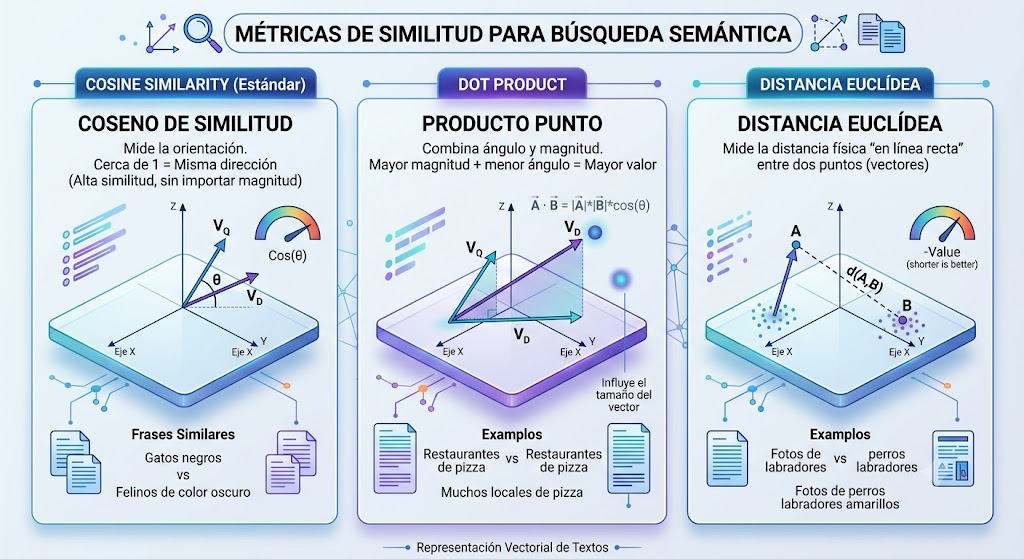

¿Entonces que es lo que hacemos en esencia?

Comparamos una cadena de texto que estamos introduciendo con todos los registros que tenemos guardados, el metodo para compararlos es mediante la transformación de todo lo que sea texto en embeddings, y luego buscar el conjunto de vectores que mas se aproximen a nuestra cadena de texto original.

El proceso se itera sobre todo el conjunto de datos comparando uno a uno las distancias y generando un indice de cercania que suele ordenarse para generar un ranking de relevancia.


Podemos ver un ejemplo con codigo:

[02_Ejemplo_metricas_simetriasemantica](https://colab.research.google.com/drive/1XJ21REcSgTBAPGqaHpSXncw00dL6Szq9?usp=sharing)



Esta tematica es muy amplia y vale la pena dedicar todo el tiempo posible ya que sienta las bases de muchisimas tecnicas y estrategias para trabjar con textos sin llegar a abusar el uso de grandes modelos LLM.


------------------
>Si te quedan preguntas no dudes en contactarme

>>>arielmeragelman@gmail.com

>>>Lic. Sebastian A. Meragelman